# Comparison — Agentic RAG vs Naive RAG

Bandingin **4 pipeline** untuk pertanyaan yang sama:
1. **Agentic** — router pilih collection (`dukcapil` / `opd` / `both` / `none`), lalu retrieve + generate. Diimpor dari `agentic_rag.py`.
2. **Naive Dukcapil** — selalu retrieve dari `dukcapil_qa` saja (hybrid BM25+Dense), lalu generate. Baseline per-collection.
3. **Naive OPD** — selalu retrieve dari `opd_directory` saja (hybrid BM25+Dense), lalu generate. Baseline per-collection.
4. **Naive Combined** — retrieve dari **KEDUA store sekaligus** (4 dukcapil + 4 opd = 8 docs), no router, generate dgn `PROMPT_COMBINED`. Diimpor dari `notebook/rag_chat_main.py`.

**Apple-to-apple head-to-head**: `Agentic` vs `Naive Combined` — keduanya bisa handle semua jenis query (dukcapil-only, opd-only, both, none). Bedanya cuma: agentic punya router LLM call di depan, naive combined langsung retrieve dari dua-duanya. Hipotesis: di dataset kecil (150+61 docs), router overhead (~2.4s) lebih besar dari ekstra retrieve cost → naive combined kemungkinan **lebih cepat**.

Naive Dukcapil & Naive OPD tetap disertakan sebagai baseline per-collection (untuk konteks: "kalau routing sempurna, berapa latency-nya?").

**Metrik:**
- Latency total + breakdown (route / retrieve / generate)
- Routing accuracy (untuk agentic vs ground-truth label)
- Per-segment latency breakdown (kapan agentic menang vs naive combined)
- Jawaban side-by-side (export CSV buat dilabel manual)

## Step 1 — Import Agentic Pipeline + Re-Setup Naive Baseline

Cara paling simple: `%run` notebook (2) supaya semua variable (`agentic_app`, `ask_agentic`, `vs_dukcapil`, `vs_opd`, `embeddings`, `llm`, `opd_docs_all`, dst.) ter-load di sini.

In [1]:
from agentic_rag import (
    agentic_app, ask_agentic,
    vs_dukcapil, vs_opd, opd_docs_all,
    retrieve_dukcapil, retrieve_opd,
    llm, embeddings,
    format_context,
    PROMPT_DUKCAPIL, PROMPT_OPD, PROMPT_BOTH, PROMPT_NONE,
)

print("✓ Agentic RAG pipeline imported")

# Import naive combined pipeline dari notebook/rag_chat_main.py
# (mirror pattern import agentic_rag.py di atas)
import sys
sys.path.insert(0, "../notebook")
from rag_chat_main import ask_main as ask_naive_combined  # noqa: E402

print("✓ Naive Combined pipeline imported (rag_chat_main.ask_main)")

c:\Users\Nafisha\Documents\RAGTrial\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


✓ Agentic RAG pipeline imported


Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


✓ Naive Combined pipeline imported (rag_chat_main.ask_main)


In [2]:
import time
import json
from typing import TypedDict, List, Literal, Dict, Any
from langchain_core.documents import Document
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import EnsembleRetriever

print("Imports OK")

Imports OK


## Step 2 — Naive Baselines

**Tiga pipeline naive:**
- **Naive Dukcapil** — hybrid BM25+Dense, locked ke `dukcapil_qa` (1 store)
- **Naive OPD** — hybrid BM25+Dense, locked ke `opd_directory` (1 store)
- **Naive Combined** — hybrid retrieve dari **dua-duanya** (4+4=8 docs), no router → ini yang head-to-head vs agentic. Sudah di-import dari `rag_chat_main.ask_main` di cell sebelumnya.

Semua pakai weights `[0.5, 0.5]` untuk fair comparison.

In [3]:
# --- Naive Dukcapil: hybrid BM25+Dense, locked ke dukcapil_qa ---
raw_d = vs_dukcapil.get()
dukcapil_docs_all = [
    Document(page_content=doc, metadata=meta)
    for doc, meta in zip(raw_d["documents"], raw_d["metadatas"])
]
_bm25_d = BM25Retriever.from_documents(dukcapil_docs_all)
_bm25_d.k = 10
_dense_d = vs_dukcapil.as_retriever(search_kwargs={"k": 10})
_ensemble_d = EnsembleRetriever(retrievers=[_bm25_d, _dense_d], weights=[0.5, 0.5])

def retrieve_dukcapil_hybrid(query: str, k: int = 5) -> List[Document]:
    return _ensemble_d.invoke(query)[:k]

# --- Naive OPD: re-use retrieve_opd dari notebook (2) yang udah hybrid ---
retrieve_opd_hybrid = retrieve_opd

print(f"Dukcapil docs in-memory utk BM25: {len(dukcapil_docs_all)}")
print(f"OPD docs in-memory utk BM25: {len(opd_docs_all)}")

Dukcapil docs in-memory utk BM25: 150
OPD docs in-memory utk BM25: 61


In [4]:
def ask_naive(question: str, source: str) -> Dict[str, Any]:
    """source: 'dukcapil' | 'opd'. Hybrid retrieval + generate. Locked ke single collection."""
    t0 = time.perf_counter()

    t_r0 = time.perf_counter()
    if source == "dukcapil":
        docs = retrieve_dukcapil_hybrid(question, k=5)
        prompt_tmpl = PROMPT_DUKCAPIL
    elif source == "opd":
        docs = retrieve_opd_hybrid(question, k=5)
        prompt_tmpl = PROMPT_OPD
    else:
        raise ValueError(f"unknown source: {source}")
    t_retrieve = time.perf_counter() - t_r0

    t_g0 = time.perf_counter()
    ctx = format_context(docs)
    answer = llm.invoke(prompt_tmpl.format(context=ctx, question=question)).content
    t_generate = time.perf_counter() - t_g0

    total = time.perf_counter() - t0
    return {
        "question": question,
        "source_used": source,
        "documents": docs,
        "answer": answer,
        "timings": {"route": 0.0, "retrieve": t_retrieve, "generate": t_generate, "total": total},
    }


# Smoke test — 3 pipelines naive
print("--- Naive Dukcapil (single collection) ---")
r = ask_naive("Apa syarat KTP-el?", source="dukcapil")
print(f"   {r['timings']['total']:.2f}s | {r['answer'][:150]}...\n")

print("--- Naive OPD (single collection) ---")
r = ask_naive("Alamat Dinas Pariwisata Batang?", source="opd")
print(f"   {r['timings']['total']:.2f}s | {r['answer'][:150]}...\n")

print("--- Naive Combined (DUA collection sekaligus, no router) ---")
r = ask_naive_combined("Mau urus KTP, ke dinas mana dan apa syaratnya?", verbose=False)
print(f"   {r['timings']['total']:.2f}s | {r['answer'][:200]}...")

--- Naive Dukcapil (single collection) ---
   7.40s | Syarat KTP-el adalah sebagai berikut:

**Untuk Warga Negara Indonesia (WNI):**
a. Telah berusia 17 tahun, sudah kawin atau pernah kawin; dan
b. Fotoko...

--- Naive OPD (single collection) ---
   5.13s | Jl. Urip Sumoharjo No. 34 Batang.
[Sumber: Dinas Pariwisata, Kepemudaan dan Olahraga, nomor 12]...

--- Naive Combined (DUA collection sekaligus, no router) ---
   14.01s | Untuk mengurus KTP, Anda dapat datang ke Dinas Kependudukan dan Pencatatan Sipil.

**Informasi Dinas:**
*   **Nama OPD:** Dinas Kependudukan dan Pencatatan Sipil
*   **Alamat:** Jl. Urip Sumoharjo No....


## Step 3 — Test Set

15 query labeled. Untuk `ambigu_*`, dua route dianggap valid pas scoring routing accuracy.

In [5]:
TEST_SET = [
    # === dukcapil_only (4) ===
    {"q": "Apa syarat penerbitan KTP-el pertama kali bagi WNI?", "label": "dukcapil"},
    {"q": "Apakah NIK yang tidak sesuai dengan format tanggal lahir dapat diubah?", "label": "dukcapil"},
    {"q": "Kalau warga negara asing tinggal tetap di Indonesia, apakah bisa punya e-KTP?", "label": "dukcapil"},
    {"q": "Bagaimana prosedur pindah domisili untuk WNA pemegang KITAP?", "label": "dukcapil"},

    # === opd_only (4) ===
    {"q": "Alamat Dinas Pariwisata Kabupaten Batang di mana?", "label": "opd"},
    {"q": "Nomor telepon Sekretariat Daerah Batang berapa?", "label": "opd"},
    {"q": "Email Bagian Hukum Setda Batang apa?", "label": "opd"},
    {"q": "Dinas apa saja yang ada di bawah Sekretariat Daerah?", "label": "opd"},

    # === both (3) ===
    {"q": "Saya mau urus KTP baru, ke dinas mana dan apa saja syaratnya?", "label": "both"},
    {"q": "Cara membuat akta kematian dan alamat kantor yang mengurusnya?", "label": "both"},
    {"q": "Mau pindah domisili ke Batang, prosedurnya gimana dan nomor telepon Disdukcapil-nya berapa?", "label": "both"},

    # === none (2) ===
    {"q": "Resep nasi goreng spesial yang enak gimana?", "label": "none"},
    {"q": "Siapa pemenang piala dunia 2022?", "label": "none"},

    # === ambigu (2) ===
    {"q": "Dinas Kependudukan dan Pencatatan Sipil Batang", "label": "ambigu_opd_or_both"},
    {"q": "Layanan dukcapil di Batang seperti apa?", "label": "ambigu_dukcapil_or_both"},
]

# Map label → set of acceptable routes (untuk scoring)
ACCEPTABLE = {
    "dukcapil": {"dukcapil"},
    "opd": {"opd"},
    "both": {"both"},
    "none": {"none"},
    "ambigu_opd_or_both": {"opd", "both"},
    "ambigu_dukcapil_or_both": {"dukcapil", "both"},
}

print(f"Test set: {len(TEST_SET)} query")

Test set: 15 query


## Step 4 — Run All 4 Pipelines

In [6]:
rows = []
for i, item in enumerate(TEST_SET, 1):
    q, label = item["q"], item["label"]
    print(f"[{i}/{len(TEST_SET)}] ({label}) {q[:70]}...")

    # 1. Agentic
    a = ask_agentic(q, verbose=False)
    # 2. Naive Dukcapil (single collection baseline)
    nd = ask_naive(q, source="dukcapil")
    # 3. Naive OPD (single collection baseline)
    no_ = ask_naive(q, source="opd")
    # 4. Naive Combined (DUA collection, no router — apple-to-apple vs agentic)
    nc = ask_naive_combined(q, verbose=False)

    rows.append({
        "question": q,
        "label": label,
        # agentic
        "agentic_route": a["route"],
        "agentic_reason": a["route_reason"],
        "agentic_answer": a["answer"],
        "agentic_t_route": round(a["timings"].get("route", 0), 3),
        "agentic_t_retrieve": round(a["timings"].get("retrieve", 0), 3),
        "agentic_t_generate": round(a["timings"].get("generate", 0), 3),
        "agentic_t_total": round(a["timings"].get("total", 0), 3),
        # naive dukcapil (single)
        "naive_dukcapil_answer": nd["answer"],
        "naive_dukcapil_t_total": round(nd["timings"]["total"], 3),
        # naive opd (single)
        "naive_opd_answer": no_["answer"],
        "naive_opd_t_total": round(no_["timings"]["total"], 3),
        # naive combined (apple-to-apple)
        "naive_combined_answer": nc["answer"],
        "naive_combined_t_retrieve": round(nc["timings"]["retrieve"], 3),
        "naive_combined_t_generate": round(nc["timings"]["generate"], 3),
        "naive_combined_t_total": round(nc["timings"]["total"], 3),
    })
print("\nDone.")

[1/15] (dukcapil) Apa syarat penerbitan KTP-el pertama kali bagi WNI?...
[2/15] (dukcapil) Apakah NIK yang tidak sesuai dengan format tanggal lahir dapat diubah?...
[3/15] (dukcapil) Kalau warga negara asing tinggal tetap di Indonesia, apakah bisa punya...
[4/15] (dukcapil) Bagaimana prosedur pindah domisili untuk WNA pemegang KITAP?...
[5/15] (opd) Alamat Dinas Pariwisata Kabupaten Batang di mana?...
[6/15] (opd) Nomor telepon Sekretariat Daerah Batang berapa?...
[7/15] (opd) Email Bagian Hukum Setda Batang apa?...
[8/15] (opd) Dinas apa saja yang ada di bawah Sekretariat Daerah?...
[9/15] (both) Saya mau urus KTP baru, ke dinas mana dan apa saja syaratnya?...
[10/15] (both) Cara membuat akta kematian dan alamat kantor yang mengurusnya?...
[11/15] (both) Mau pindah domisili ke Batang, prosedurnya gimana dan nomor telepon Di...
[12/15] (none) Resep nasi goreng spesial yang enak gimana?...
[13/15] (none) Siapa pemenang piala dunia 2022?...
[14/15] (ambigu_opd_or_both) Dinas Kependudukan

## Step 5 — Routing Accuracy

In [7]:
import pandas as pd

df = pd.DataFrame(rows)

# Routing correct kalau predicted ∈ acceptable set
df["routing_correct"] = df.apply(
    lambda r: r["agentic_route"] in ACCEPTABLE[r["label"]], axis=1
)

acc = df["routing_correct"].mean()
print(f"Routing accuracy: {acc:.1%}  ({df['routing_correct'].sum()}/{len(df)})\n")

# Breakdown per label
print("Per-label breakdown:")
print(df.groupby("label").agg(
    n=("routing_correct", "size"),
    correct=("routing_correct", "sum"),
).assign(acc=lambda x: (x["correct"]/x["n"]*100).round(1).astype(str)+"%"))

# Show wrong routes
print("\nWrong routes:")
wrong = df[~df["routing_correct"]][["question", "label", "agentic_route", "agentic_reason"]]
if len(wrong) == 0:
    print("  (none)")
else:
    for _, r in wrong.iterrows():
        print(f"  - [{r['label']}] '{r['question'][:60]}...' → predicted '{r['agentic_route']}' ({r['agentic_reason']})")

Routing accuracy: 100.0%  (15/15)

Per-label breakdown:
                         n  correct     acc
label                                      
ambigu_dukcapil_or_both  1        1  100.0%
ambigu_opd_or_both       1        1  100.0%
both                     3        3  100.0%
dukcapil                 4        4  100.0%
none                     2        2  100.0%
opd                      4        4  100.0%

Wrong routes:
  (none)


## Step 6 — Latency Comparison

Fokus utama: **Agentic vs Naive Combined** (apple-to-apple, dua-duanya bisa handle semua route).

Naive Dukcapil & Naive OPD ditampilkan sebagai konteks baseline (single-collection — ini latency "ideal" kalau routing sempurna dan kita tahu duluan harus retrieve dari mana).

In [8]:
summary = pd.DataFrame({
    "Agentic (total)":          df["agentic_t_total"],
    "Agentic (route)":          df["agentic_t_route"],
    "Agentic (retrieve)":       df["agentic_t_retrieve"],
    "Agentic (generate)":       df["agentic_t_generate"],
    "Naive Combined (total)":   df["naive_combined_t_total"],
    "Naive Combined (retrieve)": df["naive_combined_t_retrieve"],
    "Naive Combined (generate)": df["naive_combined_t_generate"],
    "Naive Dukcapil":           df["naive_dukcapil_t_total"],
    "Naive OPD":                df["naive_opd_t_total"],
})
print("Latency summary (detik):")
print(summary.describe().round(3).T[["mean", "50%", "min", "max"]])

# === Head-to-head: Agentic vs Naive Combined ===
agentic_mean  = df["agentic_t_total"].mean()
combined_mean = df["naive_combined_t_total"].mean()
delta = agentic_mean - combined_mean
winner = "Naive Combined" if  delta > 0 else "Agentic"

print("\n" + "=" * 60)
print("HEAD-TO-HEAD: Agentic vs Naive Combined (apple-to-apple)")
print("=" * 60)
print(f"  Mean Agentic total       : {agentic_mean:.2f}s")
print(f"  Mean Naive Combined total: {combined_mean:.2f}s")
print(f"  Delta (agentic - combined): {delta:+.2f}s")
print(f"  → Winner overall          : {winner}")
print(f"\n  Router overhead (agentic) : {df['agentic_t_route'].mean():.2f}s")
print(f"  (= biaya tetap LLM call setiap query buat klasifikasi)")

# === Baseline per-collection (Naive Dukcapil / OPD) — sbg konteks ===
naive_min = pd.concat([df["naive_dukcapil_t_total"], df["naive_opd_t_total"]], axis=1).min(axis=1).mean()
naive_max = pd.concat([df["naive_dukcapil_t_total"], df["naive_opd_t_total"]], axis=1).max(axis=1).mean()
print(f"\n  Baseline naive single-collection (faster): {naive_min:.2f}s")
print(f"  Baseline naive single-collection (slower): {naive_max:.2f}s")
print(f"  (= ini latency 'ideal' kalau kita tahu duluan harus query store mana)")

Latency summary (detik):
                            mean    50%    min     max
Agentic (total)            6.780  5.933  3.887  11.769
Agentic (route)            2.491  2.148  0.967   6.042
Agentic (retrieve)         0.539  0.521  0.000   1.033
Agentic (generate)         3.742  2.952  1.628   6.947
Naive Combined (total)     5.488  3.828  2.654  12.079
Naive Combined (retrieve)  0.957  0.931  0.821   1.141
Naive Combined (generate)  4.531  2.963  1.813  11.120
Naive Dukcapil             3.877  3.306  2.189   6.250
Naive OPD                  5.634  5.015  2.619  13.284

HEAD-TO-HEAD: Agentic vs Naive Combined (apple-to-apple)
  Mean Agentic total       : 6.78s
  Mean Naive Combined total: 5.49s
  Delta (agentic - combined): +1.29s
  → Winner overall          : Naive Combined

  Router overhead (agentic) : 2.49s
  (= biaya tetap LLM call setiap query buat klasifikasi)

  Baseline naive single-collection (faster): 3.34s
  Baseline naive single-collection (slower): 6.17s
  (= ini latency '

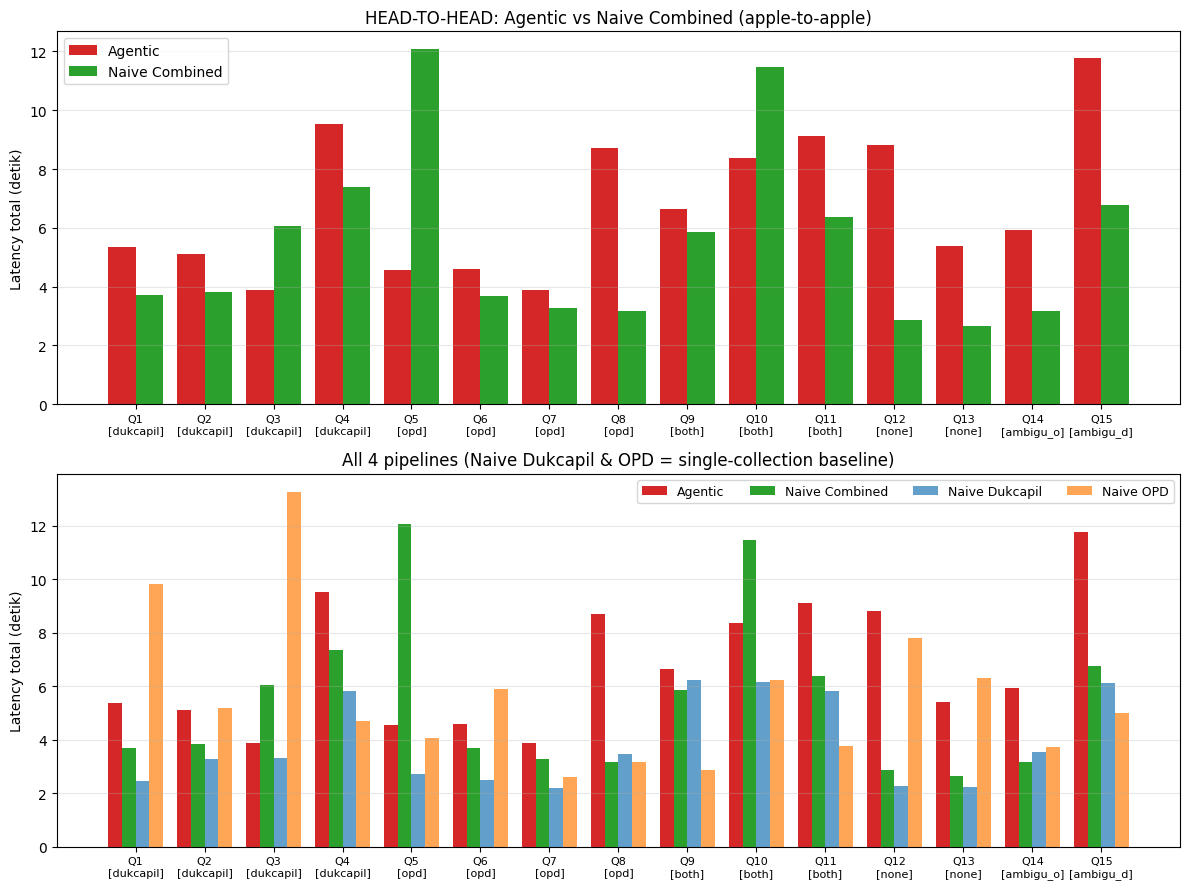

In [9]:
import matplotlib.pyplot as plt

x = list(range(len(df)))
xticks_labels = [f"Q{i+1}\n[{r['label'][:8]}]" for i, r in df.iterrows()]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 9))

# === Chart 1: Head-to-head Agentic vs Naive Combined ===
w = 0.4
ax1.bar([i - w/2 for i in x], df["agentic_t_total"],        w, label="Agentic", color="#d62728")
ax1.bar([i + w/2 for i in x], df["naive_combined_t_total"], w, label="Naive Combined", color="#2ca02c")
ax1.set_xticks(x)
ax1.set_xticklabels(xticks_labels, fontsize=8)
ax1.set_ylabel("Latency total (detik)")
ax1.set_title("HEAD-TO-HEAD: Agentic vs Naive Combined (apple-to-apple)")
ax1.legend()
ax1.grid(axis="y", alpha=0.3)

# === Chart 2: All 4 pipelines (konteks lengkap, termasuk single-collection baselines) ===
w = 0.2
ax2.bar([i - 1.5*w for i in x], df["agentic_t_total"],        w, label="Agentic",        color="#d62728")
ax2.bar([i - 0.5*w for i in x], df["naive_combined_t_total"], w, label="Naive Combined", color="#2ca02c")
ax2.bar([i + 0.5*w for i in x], df["naive_dukcapil_t_total"], w, label="Naive Dukcapil", color="#1f77b4", alpha=0.7)
ax2.bar([i + 1.5*w for i in x], df["naive_opd_t_total"],      w, label="Naive OPD",      color="#ff7f0e", alpha=0.7)
ax2.set_xticks(x)
ax2.set_xticklabels(xticks_labels, fontsize=8)
ax2.set_ylabel("Latency total (detik)")
ax2.set_title("All 4 pipelines (Naive Dukcapil & OPD = single-collection baseline)")
ax2.legend(ncol=4, loc="upper right", fontsize=9)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Step 6b — Per-segment breakdown (kapan tiap pipeline menang?)

Grouping by ground-truth label. Insight yang dicari:
- `none` (off-topic) → agentic seharusnya **menang besar** (skip retrieve+generate).
- `dukcapil` / `opd` (single domain) → naive combined kemungkinan menang (skip router LLM call).
- `both` → tie atau naive combined sedikit menang (dua-duanya retrieve dari 2 store + prompt similar).

Per-segment latency (Agentic vs Naive Combined):
                         n  agentic_mean  combined_mean  delta_s  \
label                                                              
ambigu_dukcapil_or_both  1         11.77           6.76     5.01   
ambigu_opd_or_both       1          5.93           3.17     2.76   
both                     3          8.05           7.90     0.15   
dukcapil                 4          5.97           5.24     0.73   
none                     2          7.10           2.76     4.34   
opd                      4          5.44           5.55    -0.11   

                                 winner  
label                                    
ambigu_dukcapil_or_both  naive_combined  
ambigu_opd_or_both       naive_combined  
both                     naive_combined  
dukcapil                 naive_combined  
none                     naive_combined  
opd                             agentic  


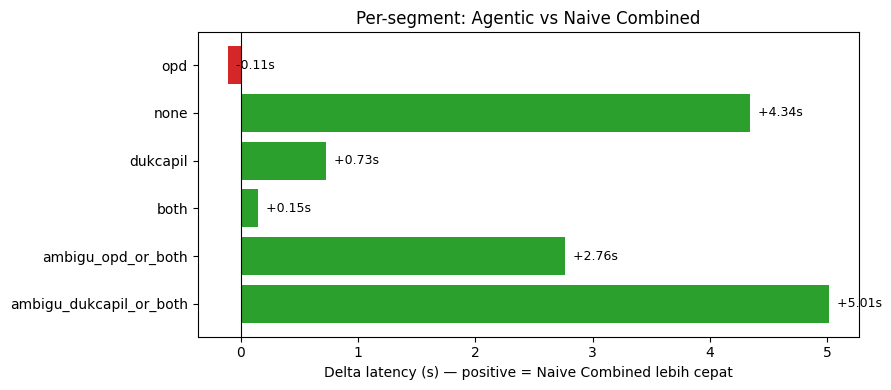

In [10]:
# Per-segment: agentic vs naive combined
seg = df.groupby("label").agg(
    n=("question", "size"),
    agentic_mean=("agentic_t_total", "mean"),
    combined_mean=("naive_combined_t_total", "mean"),
).round(2)
seg["delta_s"] = (seg["agentic_mean"] - seg["combined_mean"]).round(2)
seg["winner"] = seg["delta_s"].apply(lambda d: "naive_combined" if d > 0 else "agentic")
print("Per-segment latency (Agentic vs Naive Combined):")
print(seg)

# Visualisasi delta per segment
fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#2ca02c" if d > 0 else "#d62728" for d in seg["delta_s"]]
ax.barh(seg.index, seg["delta_s"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Delta latency (s) — positive = Naive Combined lebih cepat")
ax.set_title("Per-segment: Agentic vs Naive Combined")
for i, (lbl, d) in enumerate(zip(seg.index, seg["delta_s"])):
    ax.text(d, i, f"  {d:+.2f}s", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## Step 7 — Export Side-by-Side untuk Labeling Manual

In [11]:
export_cols = [
    "question", "label",
    "agentic_route", "agentic_reason", "routing_correct",
    "agentic_answer", "naive_combined_answer",
    "naive_dukcapil_answer", "naive_opd_answer",
    "agentic_t_total", "naive_combined_t_total",
    "naive_dukcapil_t_total", "naive_opd_t_total",
]
out_path = "comparison_results.csv"
df[export_cols].to_csv(out_path, index=False)
print(f"Exported {len(df)} rows × {len(export_cols)} cols → {out_path}")
df[export_cols].head(3)

Exported 15 rows × 13 cols → comparison_results.csv


,question,label,agentic_route,agentic_reason,routing_correct,agentic_answer,naive_combined_answer,naive_dukcapil_answer,naive_opd_answer,agentic_t_total,naive_combined_t_total,naive_dukcapil_t_total,naive_opd_t_total
0,Apa syarat penerbitan KTP-el pertama kali bagi...,dukcapil,dukcapil,syarat penerbitan KTP-el,True,Syarat penerbitan KTP-el pertama kali bagi WNI...,Syarat penerbitan KTP-el pertama kali bagi WNI...,Berdasarkan Pasal 15 Perpres Nomor 96 Tahun 20...,Informasi mengenai syarat penerbitan KTP-el pe...,5.362,3.702,2.457,9.823
1,Apakah NIK yang tidak sesuai dengan format tan...,dukcapil,dukcapil,prosedur/aturan NIK,True,Berdasarkan ketentuan Pasal 30 ayat (2) PP Nom...,Berdasarkan ketentuan Pasal 30 ayat (2) PP Nom...,Berdasarkan ketentuan Pasal 30 ayat (2) PP Nom...,Informasi mengenai perubahan NIK yang tidak se...,5.121,3.828,3.271,5.185
2,Kalau warga negara asing tinggal tetap di Indo...,dukcapil,dukcapil,aturan administrasi kependudukan (e-KTP untuk ...,True,"Ya, orang asing boleh memiliki KTP-el jika mem...","Ya, warga negara asing (WNA) pemegang izin tin...","Ya, warga negara asing yang tinggal tetap di I...",Direktori OPD yang tersedia tidak memuat infor...,3.887,6.048,3.306,13.284


## Step 8 — Verdict & Insight

Yang perlu dijawab dari hasil run:

1. **Apple-to-apple verdict (Agentic vs Naive Combined)**: cek `winner overall` di Step 6. Hipotesis: di dataset kecil ini (150+61 docs), naive combined menang karena router overhead (~2.4s) > ekstra retrieve cost (~0.3-0.5s).

2. **Per-segment behavior** (Step 6b):
   - `none` (off-topic): apakah agentic memang menang besar? Kalau iya, ini argumen untuk agentic — dia bisa skip retrieve+generate sepenuhnya buat query di luar scope.
   - `dukcapil` / `opd`: apakah naive combined menang? Kalau iya, router overhead jadi tidak worth.
   - `both`: kalau tie atau combined sedikit menang, agentic-both basically = combined + router cost.

3. **Quality check (manual)** — buka `comparison_results.csv`:
   - Apakah jawaban naive combined sama bagus dengan agentic?
   - Untuk `none`: apakah naive combined konsisten jawab "tidak ditemukan" (sesuai rule 7 PROMPT_COMBINED)?
   - Untuk single-domain: apakah retrieval dari store yang tidak relevan menggangu generate?

4. **Kapan agentic akan menang di dataset lebih besar?**
   - Kalau vector store >> 1000 docs per collection (retrieve cost naik linier; router cost flat).
   - Kalau LLM lebih mahal/lambat (router LLM bisa pakai model lebih kecil/cepat untuk routing saja).
   - Kalau ada >2 collection (combined akan retrieve dari N store, agentic tetap 1).